## Техническое повторное исполнение архивного снимка

Очистка выходов и actual clean-kernel execution выполняются через nbclient. Этот документ воспроизводит чтение существующих исторических результатов; сегментация и научные модели заново не рассчитываются.

Исторический научный текст ниже сохранён; его прежние утверждения и планы не являются новыми проверенными результатами. Старые language-review и snapshot-манифесты относятся к резервной исходной версии и не удостоверяют эту техническую редакцию.



**COMPLETE: все ячейки читателя выполнены.**

UTC: 2026-09-14T14:09:39.754476+00:00; выполнено кодовых ячеек: 9; без ошибки: 9.



In [1]:
from pathlib import Path
import ast, base64, csv, hashlib, html, io, json, os, re
from IPython.display import display, HTML, Image
NOTEBOOK_DIR = Path.cwd().resolve()
INPUT_PROVENANCE = []
MISSING_INPUTS = []

def read_historic(relative_path, expected_sha256, explanation):
    path = (NOTEBOOK_DIR / relative_path).resolve()
    record = dict(path=str(path), relative_path=relative_path, expected_sha256=expected_sha256, explanation=explanation)
    if not path.is_file():
        record['status'] = 'missing'; MISSING_INPUTS.append(record)
        raise FileNotFoundError('INCOMPLETE / MISSING INPUT: ' + str(path) + '; ' + explanation)
    payload = path.read_bytes()
    record['sha256'] = hashlib.sha256(payload).hexdigest()
    if record['sha256'] != expected_sha256:
        record['status'] = 'historical_hash_mismatch'; MISSING_INPUTS.append(record)
        raise ValueError('INCOMPLETE / HISTORICAL HASH MISMATCH: ' + str(path))
    record['status'] = 'verified'; INPUT_PROVENANCE.append(record)
    return payload

def blocked(paths, explanation):
    missing = [dict(path=str((NOTEBOOK_DIR/p).resolve()), relative_path=p, status='missing_historical_input_or_identity', explanation=explanation) for p in paths]
    MISSING_INPUTS.extend(missing)
    raise FileNotFoundError('INCOMPLETE / MISSING HISTORICAL INPUTS: ' + '; '.join(r['path'] for r in missing) + '; ' + explanation)

def scalar(value):
    if value in ('True', 'False'): return value == 'True'
    try: return json.loads(value)
    except (ValueError, TypeError): return value

def csv_rows(payload, numeric=True):
    rows = list(csv.DictReader(io.StringIO(payload.decode('utf-8-sig'))))
    if numeric:
        return [{k:scalar(v) for k,v in row.items() if v!=''} for row in rows]
    return rows

def show_table(rows):
    columns = list(dict.fromkeys(k for row in rows for k in row))
    body = '<div style="overflow:auto"><table><thead><tr>' + ''.join('<th>'+html.escape(k)+'</th>' for k in columns) + '</tr></thead><tbody>'
    body += ''.join('<tr>'+''.join('<td>'+html.escape(str(row.get(k,'')))+'</td>' for k in columns)+'</tr>' for row in rows)
    display(HTML(body+'</tbody></table></div>'))

def presentation_functions(payload, names, namespace):
    tree = ast.parse(payload.decode('utf-8-sig'))
    nodes = [n for n in tree.body if isinstance(n,ast.FunctionDef) and n.name in names]
    if {n.name for n in nodes} != set(names): raise RuntimeError('Missing historical presentation function')
    # Execute only explicitly selected pure presentation functions. No module imports,
    # builders, segmentation, numerical fitting, file writes or main entry points.
    exec(compile(ast.Module(body=nodes,type_ignores=[]),'<pinned historical presentation functions>','exec'),namespace)
    return namespace

print('ACTUAL CLEAN KERNEL; cwd=' + str(NOTEBOOK_DIR) + '; pid=' + str(os.getpid()))


ACTUAL CLEAN KERNEL; cwd=D:\Аспа\Kalmykov_PhD\Colab Notebooks\archive\private\21.03_before_function_analysis_20260909; pid=12296


[21.00 — карта серии и пересборка](21.00_Карта_4D_сердца_и_RR.md) · [21.01 — обзор 4D](21.01_4D_сердце_интерактивно.ipynb)

# Проверка автоматической сегментации сердца в 4D-КТ

**Статус:** исследовательский вычислительный тест; автоматические маски ожидают
покадровой экспертной проверки.

## Задача и происхождение масок

Ноутбук проверяет динамику формы сердца и объёмов четырёх камер на 39 фазах
контрастной 4D-КТ Adam, Nix и Georg. Ручная сегментация Inobitec остаётся
каноническим анатомическим референсом проекта, но в этот расчёт ещё не включена.

TotalSegmentator 2.18.0 запускался в независимых задачах `total/heart` и
`heartchambers_highres`. Маска крови — объединение четырёх камер без аорты и
лёгочной артерии. Геометрическая разность «всё сердце минус кровь» не является
валидированной маской полного миокарда. Класс `heart_myocardium` охватывает
преимущественно миокард ЛЖ и межжелудочковую перегородку.

## Что непосредственно получено из DICOM

Для каждого испытуемого ниже приведены: каталог исходной серии и число файлов,
`NominalPercentageOfCardiacPhase`, приватные метки GE `RpeakTimeStamps
(0049,100C)`, рассчитанные по ним R–R и ЧСС, распределение
`AvgHeartRateForImage`, показатели ЧСС при подтверждении и до него, временное
разрешение реконструкции, контроль по `TemporalCenterViewAngle`, тип монитора,
нерасшифрованные приватные коды и наличие GE ECG Report. Приватные коды
перенесены дословно: их числовым значениям не приписан смысл без документации
производителя. Стандартной DICOM-последовательности `WaveformSequence` нет.

У Adam и Nix доступны только растровые полосы из GE ECG Report с предупреждением
`Not for Diagnostic ECG use`; они не содержат калиброванных цифровых отсчётов.
У Georg отчёт ECG Report не найден.

Для каждого испытуемого 3D-маски, схематическая кривая P–QRS–T и графики
объёмов объединены в одном интерактивном представлении. Выбор фазы одним
ползунком одновременно обновляет геометрию и выделяет соответствующую точку
каждой камеры. Кривая P–QRS–T служит только ориентиром внутри R–R и не является
индивидуальной ЭКГ. Точное сопоставление КТ-фаз с электрическими и
механическими фазами сердца составляет отдельный этап проверки.

## Объединение соседних сердечных циклов

Основной график использует время в миллисекундах. Для Adam и Nix оно отсчитано
от первой R-метки и показано непрерывно через границу соседних интервалов; в
скобках у каждой точки указан процент соответствующего R–R. Для Georg короткий
и длинный интервалы показаны на двух отдельных панелях, каждая со своей шкалой
миллисекунд после R-триггера. Одинаковый процент двух разных R–R не считается
одинаковой механической фазой.

Для Adam и Nix объединение в отдельной численной модели предварительно
разрешено, поскольку относительное различие медианной ЧСС соседних циклов не
превышает рабочий порог 10%. Этот порог методический и ещё не валидирован
физиологически.

Средняя кривая построена периодической моделью Фурье с двумя гармониками.
Модель допускает отдельную аддитивную поправку для каждого записанного цикла;
поправки центрированы относительно нуля и регуляризованы, чтобы частично
наблюдаемый второй цикл не определял форму кривой произвольно. Равенство
V(0%) = V(100%) следует из периодического базиса, а не из добавления фиктивной
точки. Все исходные точки и принадлежность циклу сохранены. Остаточная ошибка
модели и рассчитанные межцикловые поправки записаны в итоговую таблицу.

Это описательная аппроксимация, а не доверительный интервал и не доказательство
того, что два цикла физиологически тождественны. В исходном представлении PCHIP
по-прежнему строится отдельно внутри наблюдаемого участка каждого цикла.

## Georg: почему объединение запрещено

Во всех 3840 изображениях серии 309 сохранена одна тройка R-меток: −0,026;
0,465 и 1,624 с. Из неё следуют R–R 491 и 1159 мс, или 122,20 и
51,77 уд/мин. `AvgHeartRateForImage` независимо повторяет эту пару: 122 уд/мин
в 2048 изображениях и 52 уд/мин в 1792 изображениях. Максимальное расхождение
проверки по `TemporalCenterViewAngle` составляет 7,66 мс. Следовательно,
коротко-длинная пара использована реконструкцией и не возникла из-за нашего
объединения таблиц или нормирования графика.

Пара совместима как минимум с тремя классами причин: преждевременный комплекс
с последующей паузой; лишний или пропущенный синхроимпульс при распознавании
R-зубца; редактирование/отбор циклов системой реконструкции. ЧСС до
подтверждения у Georg изменялась сильнее, чем у Adam и Nix (SD 10,1 против
примерно 5,5 уд/мин), но это не устанавливает механизм и не является диагнозом.
Без соседних R-меток, исходной цифровой ЭКГ и журнала ECG-edit различить эти
варианты нельзя.

Первичный анализ Georg поэтому сохраняет оба участка раздельно и не
экстраполирует их в общий цикл. Рабочая проверка должна идти в таком порядке:

1. запросить с консоли сканера исходную полосу/журнал кардиосинхронизации и,
   если сохранялись, необработанные временные метки синхроимпульсов;
2. проверить журнал ECG-edit/arrhythmia rejection и расшифровать приватные коды
   по документации конкретной версии GE;
3. посрезово сравнить короткий и длинный участки на двойные контуры, разрывы
   движения камер и коронарных артерий;
4. повторить расчёт как анализ чувствительности: оба участка раздельно;
   только длинный участок; абсолютное время после R. Ни один вариант не считать
   основным без внешнего подтверждения;
5. если дополнительные данные недоступны, исключить Georg из композитных
   фазовых оценок, но оставить как отдельный случай контроля качества с отрицательным результатом.

## Ограничения сегментации и неопределённости

Межмодельный Dice 0,906–0,947 показывает согласие автоматических выходов, а не
точность относительно анатомии. Соседний скачок объёма модельного миокарда
достигает 21,5–26,2%, отдельных камер — 44,1%. Клапанные плоскости, устья
сосудов, ушки предсердий и тонкие стенки требуют посрезовой проверки.

Доверительный интервал точности сегментации пока не рассчитан. Нужны независимые
разметки двух экспертов, повторная разметка части кадров одним экспертом и
метрики объёма, Dice, поверхностного Dice, среднего симметричного расстояния и
95-го процентиля расстояния Хаусдорфа. Фазы одного сердца зависимы, поэтому
интервалы следует строить кластерным бутстрэпом по испытуемым. При трёх
испытуемых популяционный интервал будет только пилотным.

## Литературные основания

- [DICOM PS3.3, Cardiac Synchronization Macro](https://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.7.6.16.2.html): `NominalPercentageOfCardiacPhase` задаёт номинальное время относительно предшествующего R-зубца в процентах номинального R–R.
- [Matsutani et al., 2008](https://pubmed.ncbi.nlm.nih.gov/18577814/): при аритмиях в кардиальной КТ применяют ECG-edit, включая удаление короткого R–R и выбор фазы из длинного интервала.
- [Kondo et al., 2014](https://pubmed.ncbi.nlm.nih.gov/24582039/): желудочковые экстрасистолы могут сопровождаться постэкстрасистолической компенсаторной паузой; это возможная, но не доказанная здесь причина коротко-длинной пары.
- [Celeng et al., 2016](https://doi.org/10.1007/s10554-015-0755-2): одинаковый процент R–R может соответствовать разному абсолютному времени механического события при различной ЧСС.
- [Robinson et al., 2024](https://doi.org/10.1186/s44156-024-00051-2): механические фазы определяются клапанными событиями, а не одним фиксированным процентом R–R.
- [Metrics Reloaded](https://doi.org/10.1038/s41592-023-02151-z): метрики валидации сегментации следует выбирать с учётом клинической задачи.
- [Warfield et al., 2004](https://doi.org/10.1109/TMI.2004.828354): STAPLE позволяет вероятностно объединять экспертные разметки.


## Исходные данные кардиосинхронизации

В первой таблице собраны субъектные поля DICOM, включая исходные фазы, R-метки, частоты, параметры реконструкции и наличие GE ECG Report: [cardiac_dicom_metadata_by_subject.csv](heart_rr_analysis/cardiac_dicom_metadata_by_subject.csv). Во второй таблице приведены отдельные R–R-интервалы. Полная таблица: [cardiac_gating_source_data.csv](heart_rr_analysis/cardiac_gating_source_data.csv).

In [2]:
# Исходные временные метки GE и рассчитанные по ним R–R/ЧСС.
base_render = presentation_functions(read_historic('analyze_subtraction_and_rr.py', 'aa243335587404c0f422bd1019070a1269be8c78cdbe8ecf2061aae5f0986bc7', 'Own historical generator; only two pure formatting functions, no main or numerical pipeline.'), ['subject_dicom_table_html','gating_source_table_html'], {})
subject_rows = csv_rows(read_historic('heart_rr_analysis/cardiac_dicom_metadata_by_subject.csv', '3ccc3626ca6bb3793b045fe868c86ac12e2010d23a2ce6da320df7084094496a', 'Own historical snapshot table, read directly; SHA-256 fixed before execution.'),numeric=False)
for row in subject_rows: row['ecg_report_available'] = row['ecg_report_available'] == 'True'
display(HTML(base_render['subject_dicom_table_html'](subject_rows)))
display(HTML(base_render['gating_source_table_html'](csv_rows(read_historic('heart_rr_analysis/cardiac_gating_source_data.csv', '6f4325d738cc6aee194d419be0a497b2fff2baf2407ceed6fb06cb6f3f33b234', 'Own historical snapshot table, read directly; SHA-256 fixed before execution.'),numeric=False))))

Испытуемый,Серия / DICOM,"Фазы, %","R-метки, с","R–R, мс",ЧСС по R–R,AvgHeartRateForImage (n),ЧСС confirm; до confirm,Временное разрешение / проверка CVA,Монитор / приватные коды,GE ECG Report
ADAM,307_all_7cc2a4cbn=3072,12; 22; 31; 41; 50; 60; 70; 79; 89; 98; 108; 117,-0.026; 0.901; 1.832,927; 931,64.725; 64.447,65 (n=2560); 64 (n=512),"64; 66,5 (60–84), SD=5,5, n=67","0,140 с; остаток CVA ≤ 3,87 мс",ICM; gating=0; DAS=0; recon=01; autoHR=00; optimizedHR=00; sectors=01; triggers=9491; frequency=3514.285714; position=167.53289794921875,есть; 12–117% R–R; Scan heart rate statistics: 63/65/71
NIX,307_all_4a733c2en=3072,14; 23; 33; 43; 53; 62; 72; 82; 92; 101; 111; 121,-0.026; 0.796; 1.583,822; 787,72.993; 76.239,73 (n=2304); 76 (n=768),"72; 78,3 (61–89), SD=5,5, n=78","0,140 с; остаток CVA ≤ 6,05 мс",ICM; gating=0; DAS=0; recon=01; autoHR=00; optimizedHR=00; sectors=01; triggers=9122; frequency=3514.285714; position=21.50779914855957,есть; 14–121% R–R; Scan heart rate statistics: 71/80/86; Breath-hold recording heart rate statistics: 60/62/67
GEORG,309_all_tf_74957fa9n=3840,23; 33; 43; 53; 63; 73; 83; 93; 103; 113; 123; 134; 144; 154; 164,-0.026; 0.465; 1.624,491; 1159,122.2; 51.769,122 (n=2048); 52 (n=1792),"60; 68,2 (49–96), SD=10,1, n=67","0,140 с; остаток CVA ≤ 7,66 мс",ICM; gating=0; DAS=0; recon=01; autoHR=00; optimizedHR=00; sectors=01; triggers=8089; frequency=3514.285714; position=9.013400077819824,нет


Испытуемый,Цикл,"R начало, с","R конец, с","R–R, мс","ЧСС по R–R, уд/мин","ЧСС изображения, уд/мин","ЧСС при подтверждении, уд/мин","До подтверждения: средняя (мин.–макс.), уд/мин"
ADAM,1,"-0,026","0,901","927,0","64,72",65,64,"66,5 (60–84)"
ADAM,2,"0,901","1,832","931,0","64,45",64,64,"66,5 (60–84)"
NIX,1,"-0,026","0,796","822,0","72,99",73,72,"78,3 (61–89)"
NIX,2,"0,796","1,583","787,0","76,24",76,72,"78,3 (61–89)"
GEORG,1,"-0,026","0,465","491,0","122,20",122,60,"68,2 (49–96)"
GEORG,2,"0,465","1,624","1159,0","51,77",52,60,"68,2 (49–96)"


## Отдельный разбор коротко-длинной пары Georg

DICOM подтверждает использование реконструкцией интервалов 491 и 1159 мс, но не позволяет установить причину. Возможны преждевременный комплекс с паузой, лишний либо пропущенный R-триггер или ECG-edit. До получения цифровой ЭКГ и журнала редактирования оба участка анализируются раздельно. При отсутствии дополнительных данных Georg не включается в композитные фазовые оценки. Временные графики короткого и длинного интервалов показаны на отдельных панелях в миллисекундах после R; проценты оставлены в скобках как вторичная координата. Литературные основания: [Matsutani et al., 2008](https://pubmed.ncbi.nlm.nih.gov/18577814/) и [Kondo et al., 2014](https://pubmed.ncbi.nlm.nih.gov/24582039/).

## ADAM: синхронное представление 3D-масок, ЭКГ и объёмов

In [3]:
# Один ползунок одновременно меняет 3D-фазу и выделяет соответствующие точки на схеме ЭКГ и графиках объёма.
figure_bytes = read_historic('heart_rr_analysis/adam_heart_minus_blood_4d.html', '252c1acda1e484b37150f5ace55e2a6ed4e43e9485cc62b46e2cd7c6477b8795', 'Own independent historical 3D/ECG/volume figure. Its bytes are read and hash-verified; only a local iframe is emitted, no recomputation.')
display(HTML('<iframe src="heart_rr_analysis/adam_heart_minus_blood_4d.html" width="100%" height="1080" style="border:0" title="ADAM historical synchronized figure"></iframe>'))

C:\PC\Python\Lib\site-packages\IPython\core\display.py:446: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


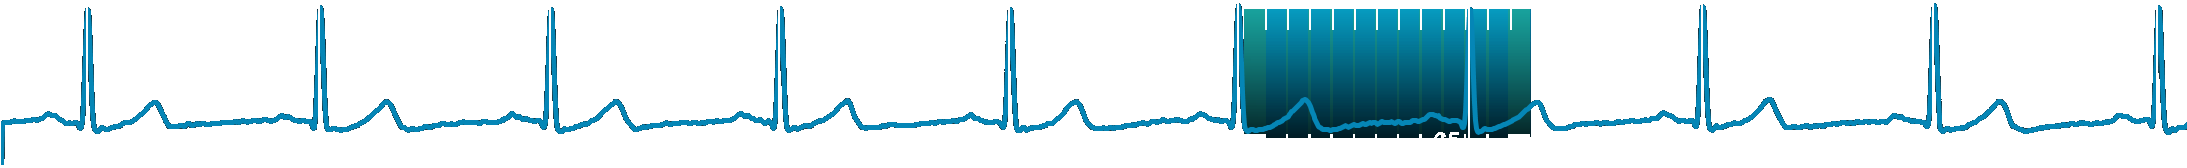

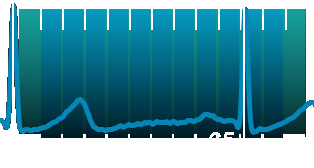

In [4]:
# Общий вид полосы GE и точный фрагмент выделенного интервала встроены как PNG.
display(Image(data=read_historic('heart_rr_analysis/ecg_traces/adam_series307_ecg_gating_strip.png', '5f320730017eea5f3d7c3921d303f8f93c2b5389c74f9f95a953f85c957cc52d', 'Own historical ECG PNG; direct read from snapshot, not notebook output.')))
display(Image(data=read_historic('heart_rr_analysis/ecg_traces/adam_series307_ecg_scan_window.png', 'eab6488a60174dfcaa819b5101a6a0c3dbedeb8389b1c550dc7cda3e0b25291e', 'Own historical ECG PNG; direct read from snapshot, not notebook output.')))

## NIX: синхронное представление 3D-масок, ЭКГ и объёмов

In [5]:
# Один ползунок одновременно меняет 3D-фазу и выделяет соответствующие точки на схеме ЭКГ и графиках объёма.
figure_bytes = read_historic('heart_rr_analysis/nix_heart_minus_blood_4d.html', 'bcf54cc96b70cc98ae40cd3e42bc98a12fcbb84bb3d133f9a4c6c9907f362c4b', 'Own independent historical 3D/ECG/volume figure. Its bytes are read and hash-verified; only a local iframe is emitted, no recomputation.')
display(HTML('<iframe src="heart_rr_analysis/nix_heart_minus_blood_4d.html" width="100%" height="1080" style="border:0" title="NIX historical synchronized figure"></iframe>'))

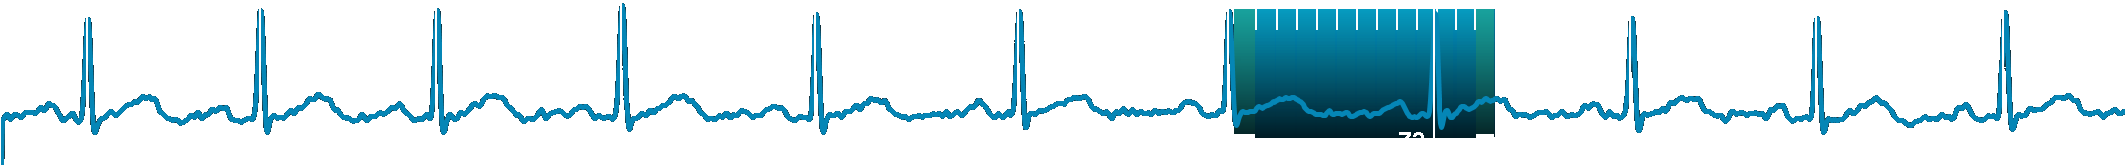

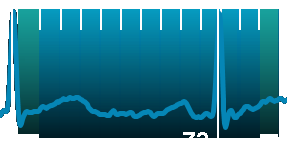

In [6]:
# Общий вид полосы GE и точный фрагмент выделенного интервала встроены как PNG.
display(Image(data=read_historic('heart_rr_analysis/ecg_traces/nix_series307_ecg_gating_strip.png', '25dfd621ae49522e9c3da223477eff1e548f44562eaa711ae19750785f682f95', 'Own historical ECG PNG; direct read from snapshot, not notebook output.')))
display(Image(data=read_historic('heart_rr_analysis/ecg_traces/nix_series307_ecg_scan_window.png', 'd5b31a068a9155dd2096690d810cbd7d1a505688b71b94fdb4d4e01a7e0dacda', 'Own historical ECG PNG; direct read from snapshot, not notebook output.')))

## GEORG: синхронное представление 3D-масок, ЭКГ и объёмов

In [7]:
# Один ползунок одновременно меняет 3D-фазу и выделяет соответствующие точки на схеме ЭКГ и графиках объёма.
figure_bytes = read_historic('heart_rr_analysis/georg_heart_minus_blood_4d.html', 'f0d8c1b199d6b040428c08e190146c0305c0e59350ddef884fab1c2053b3ab18', 'Own independent historical 3D/ECG/volume figure. Its bytes are read and hash-verified; only a local iframe is emitted, no recomputation.')
display(HTML('<iframe src="heart_rr_analysis/georg_heart_minus_blood_4d.html" width="100%" height="1080" style="border:0" title="GEORG historical synchronized figure"></iframe>'))

**GEORG:** отчёт GE ECG Report в доступных КТ-данных не найден.

## Расчётные изменения объёмов по фазам

Изменения между фактически реконструированными фазами каждого отдельного цикла приведены для всех трёх испытуемых: [chamber_volume_changes_measured_cycles.csv](heart_rr_analysis/chamber_volume_changes_measured_cycles.csv). Периодические профили с шагом 1% R–R рассчитаны только для Adam и Nix: относительное различие медианной ЧСС между их циклами не превышает методический порог 10%. Для Georg объединение отклонено из-за ЧСС 122 и 52 уд/мин; два частичных цикла показаны раздельно без экстраполяции. Таблица профилей содержит объём, изменение относительно 0%, остаток модели, межцикловые поправки и изменение относительно предыдущего шага: [chamber_volume_changes_closed_cycle.csv](heart_rr_analysis/chamber_volume_changes_closed_cycle.csv). Сводка по диапазонам и фазам экстремумов: [chamber_volume_changes_closed_cycle_summary.csv](heart_rr_analysis/chamber_volume_changes_closed_cycle_summary.csv).

In [8]:
# Сводка периодических расчётных профилей четырёх камер.
show_table(csv_rows(read_historic('heart_rr_analysis/chamber_volume_changes_closed_cycle_summary.csv', '6b4a64c0448b44d34a0f12153f9131635b58e0d4e02453c390451bc5b8c5de50', 'Own historical calculated periodic profiles summary; display without refitting.')))

subject,chamber_key,chamber_label,label_ru,status,method,harmonics,harmonic_ridge,cycle_contrast_ridge,cycle_offsets_ml,residual_rmse_ml,residual_max_abs_ml,boundary_volume_ml,minimum_ml,maximum_ml,peak_to_peak_ml,phase_of_minimum_percent,phase_of_maximum_percent,measured_phase_count,measured_observation_count
adam,heart_atrium_left,Левое предсердие,Левое предсердие,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': -0.5348734888520461, '2': 0.5348734888520461}",2.543505421519102,3.6381557393708164,43.66126438856685,43.14816603069076,86.42476680857601,43.27660077788525,3.0,37.0,12,12
adam,heart_ventricle_left,Левый желудочек,Левый желудочек,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': 0.6838642366532562, '2': -0.6838642366532562}",2.81399834509858,5.693623414629016,151.63956726414733,98.92573512795289,152.20454692783778,53.27881179988489,36.0,96.0,12,12
adam,heart_atrium_right,Правое предсердие,Правое предсердие,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': -1.110201070994147, '2': 1.110201070994147}",5.10022870935604,8.909380713754999,65.26085519914429,65.26085519914429,113.52542454547626,48.26456934633197,0.0,36.0,12,12
adam,heart_ventricle_right,Правый желудочек,Правый желудочек,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': 2.4055860161325064, '2': -2.4055860161325064}",5.479927233935695,9.114910915816239,212.6788308243542,124.90884754646997,213.5213953570758,88.61254781060582,36.0,97.0,12,12
nix,heart_atrium_left,Левое предсердие,Левое предсердие,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': 0.740979395294293, '2': -0.740979395294293}",4.169044463441518,7.51235370330366,37.418453191700195,36.28502692960333,84.58079230610984,48.29576537650651,4.0,41.0,12,12
nix,heart_ventricle_left,Левый желудочек,Левый желудочек,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': -1.6204725949522663, '2': 1.6204725949522663}",2.538592471321868,4.6354362704686025,150.60371883439086,89.44560972672477,153.9185926279113,64.47298290118653,40.0,91.0,12,12
nix,heart_atrium_right,Правое предсердие,Правое предсердие,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': 1.9395846984707583, '2': -1.9395846984707583}",6.436400913925339,12.350508472462948,51.1501279159701,51.12101274469085,113.60183242870183,62.480819684010974,1.0,42.0,12,12
nix,heart_ventricle_right,Правый желудочек,Правый желудочек,calculated_provisional,periodic_fourier_ridge_with_cycle_contrasts,2,0.1,1.0,"{'1': -3.667530379129279, '2': 3.667530379129279}",5.622446517443634,10.142397538077034,228.87290193396433,128.78147232219715,232.23028882654143,103.44881650434428,41.0,91.0,12,12
georg,heart_atrium_left,Левое предсердие,Левое предсердие,not_calculated_cycle_merge_rejected,not_calculated,,,,,,,,,,,,,14,15
georg,heart_ventricle_left,Левый желудочек,Левый желудочек,not_calculated_cycle_merge_rejected,not_calculated,,,,,,,,,,,,,14,15


In [9]:
display({'application/json': {'input_provenance': INPUT_PROVENANCE, 'missing_inputs': MISSING_INPUTS}, 'text/plain': 'Historical input audit: verified reads=' + str(len(INPUT_PROVENANCE)) + '; missing or unverified=' + str(len(MISSING_INPUTS))}, raw=True)

Historical input audit: verified reads=11; missing or unverified=0